# IF3270 Pembelajaran Mesin - Tugas Besar 1
Kelompok: 56
Anggota:
- Andi Farhan Hidayat 13523128
- Andri Nurdianto 13523145
- Rafael Marchel Darma W 13523146

## Import Libraries

In [29]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [30]:
df = pd.read_csv("../datasetml_2026.csv")

## EDA

In [31]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [32]:
df.isna().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

In [33]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
dtype: object

In [34]:
print(df.shape)
print(df.head(10))

(10000, 12)
       cgpa  backlogs college_tier  country university_ranking_band  \
0  7.397371         1       Tier 2   Canada                 100-300   
1  6.889389         0       Tier 3       UK                    300+   
2  7.518151         0       Tier 1       UK                 100-300   
3  8.218424         0       Tier 2       UK                 100-300   
4  6.812677         1       Tier 2      USA                 100-300   
5  6.812690         0       Tier 1  Germany                    300+   
6  8.263370         1       Tier 3    India                    300+   
7  7.613948         2       Tier 3   Canada                    300+   
8  6.624420         0       Tier 2    India                 100-300   
9  7.434048         3       Tier 3  Germany                 Top 100   

   internship_count  aptitude_score  communication_score specialization  \
0                 2       53.574150            64.177062   Data Science   
1                 1       60.687750            88.346052

In [35]:
df.nunique()

cgpa                        9998
backlogs                       7
college_tier                   3
country                        5
university_ranking_band        3
internship_count               6
aptitude_score              9720
communication_score         9835
specialization                 5
industry                       6
internship_quality_score    9961
placement_status               2
dtype: int64

In [36]:
df['placement_status'].value_counts()

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

In [37]:
numeric_col = [
    "cgpa",
    "backlogs",
    "internship_count",
    "aptitude_score",
    "communication_score",
    "internship_quality_score"
]

categorical_cols = [
    "college tier",
    "country",
    "university_ranking_band",
    "specialization",
    "industry",
    "placement_status"
]

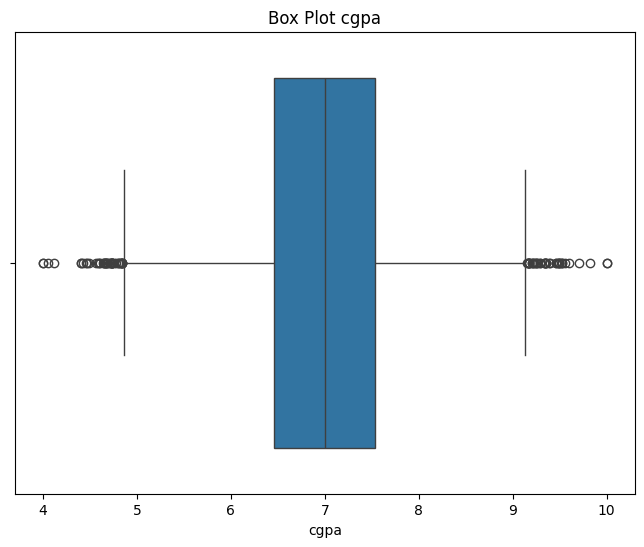

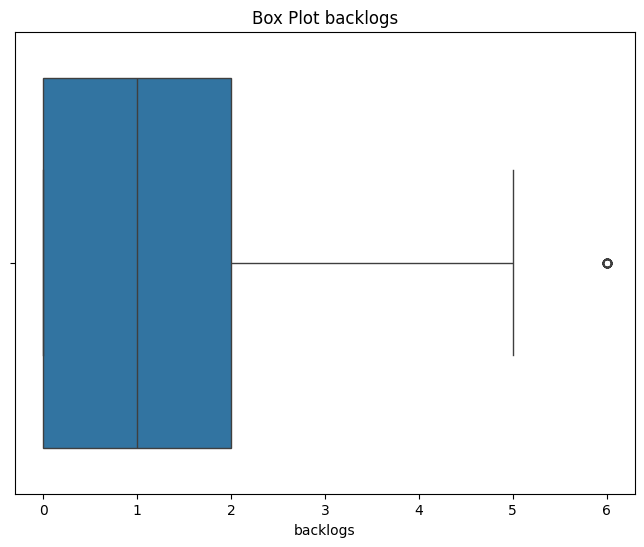

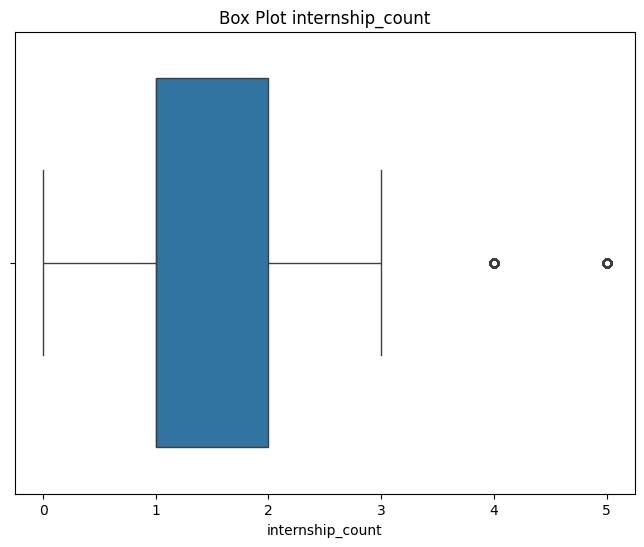

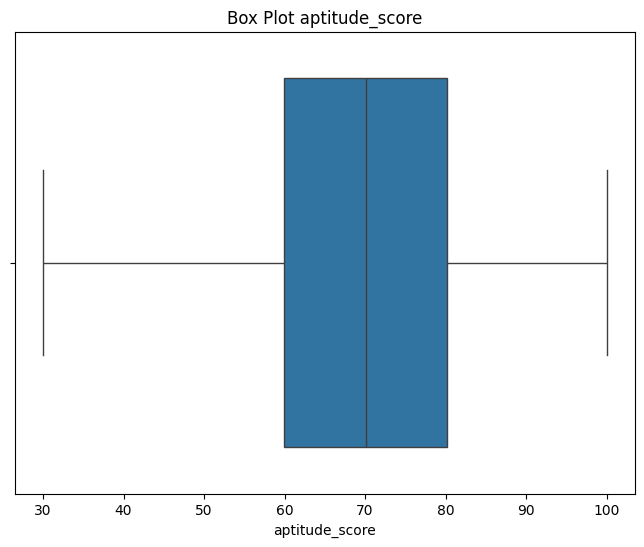

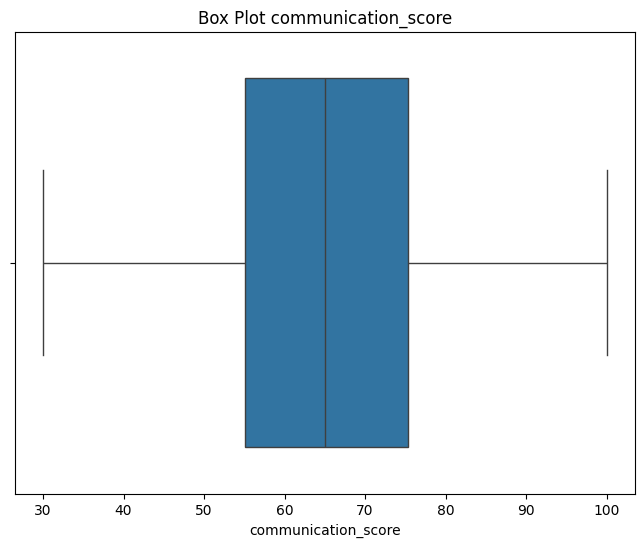

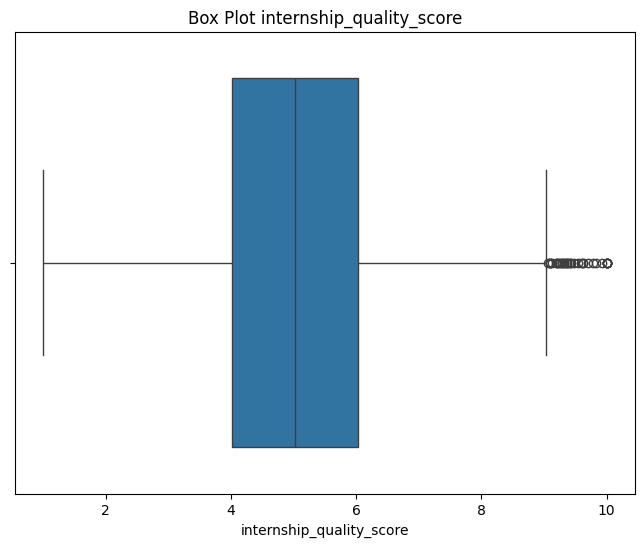

In [38]:
for col in numeric_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot {col}')
    plt.show

In [39]:
df.duplicated().sum()

np.int64(0)

In [41]:
# University ranking encoding
univ_rank = {"Top 100": 1, "100-300": 2, "300+": 3}
df["university_ranking_band"] = df["university_ranking_band"].map(univ_rank)

# Placement status encoding
placement_encode = {"Not Placed": 0, "Placed": 1}
df["placement_status"] = df["placement_status"].map(placement_encode)

In [42]:
X = df.drop("placement_status", axis=1)
y = df["placement_status"]

In [43]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling